# 4. XGBoost

In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_train.parquet"
)

X_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/X_test.parquet"
)

y_train = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_train.parquet"
)["Label"]

y_test = pd.read_parquet(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/y_test.parquet"
)["Label"]

label_mapping = pd.read_csv(
    "/kaggle/input/datasets/nadianoumee/ids2017-preprocessing/label_mapping.csv"
)

class_names = label_mapping["class_name"].values
classes = np.arange(len(class_names))

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1785379, 77)
(446345, 77)
(1785379,)
(446345,)


In [2]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

print("y_test shape:", y_test.shape)
print("y_test_bin shape:", y_test_bin.shape)

y_test shape: (446345,)
y_test_bin shape: (446345, 15)


In [3]:
from xgboost import XGBClassifier

xgb_before = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb_before.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1, num_class=15, ...)

In [4]:
import joblib

joblib.dump(
    xgb_before,
    "/kaggle/working/xgb_model.pkl"
)

print("XGBoost model saved.")

XGBoost model saved.


In [5]:
y_pred_xgb_before = xgb_before.predict(X_test)

y_prob_xgb_before = xgb_before.predict_proba(X_test)

In [6]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_xgb_before)

precision_weighted = precision_score(
    y_test, y_pred_xgb_before,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_test, y_pred_xgb_before,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_test, y_pred_xgb_before,
    average="weighted",
    zero_division=0
)

precision_macro = precision_score(
    y_test, y_pred_xgb_before,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_test, y_pred_xgb_before,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_test, y_pred_xgb_before,
    average="macro",
    zero_division=0
)

mcc = matthews_corrcoef(y_test, y_pred_xgb_before)

auc = roc_auc_score(
    y_test_bin,
    y_prob_xgb_before,
    multi_class="ovr",
    average="weighted"
)

print(f"Accuracy           : {accuracy:.4f}")
print(f"Weighted Precision : {precision_weighted:.4f}")
print(f"Weighted Recall    : {recall_weighted:.4f}")
print(f"Weighted F1        : {f1_weighted:.4f}")
print(f"Macro Precision    : {precision_macro:.4f}")
print(f"Macro Recall       : {recall_macro:.4f}")
print(f"Macro F1           : {f1_macro:.4f}")
print(f"MCC                : {mcc:.4f}")
print(f"AUC                : {auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_xgb_before,
        target_names=class_names,
        zero_division=0
    )
)

Accuracy           : 0.9986
Weighted Precision : 0.9986
Weighted Recall    : 0.9986
Weighted F1        : 0.9985
Macro Precision    : 0.8974
Macro Recall       : 0.8107
Macro F1           : 0.8237
MCC                : 0.9948
AUC                : 1.0000

Classification Report:
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    379047
                       Bot       0.95      0.56      0.70       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.95      0.99      0.97      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      0.99      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      

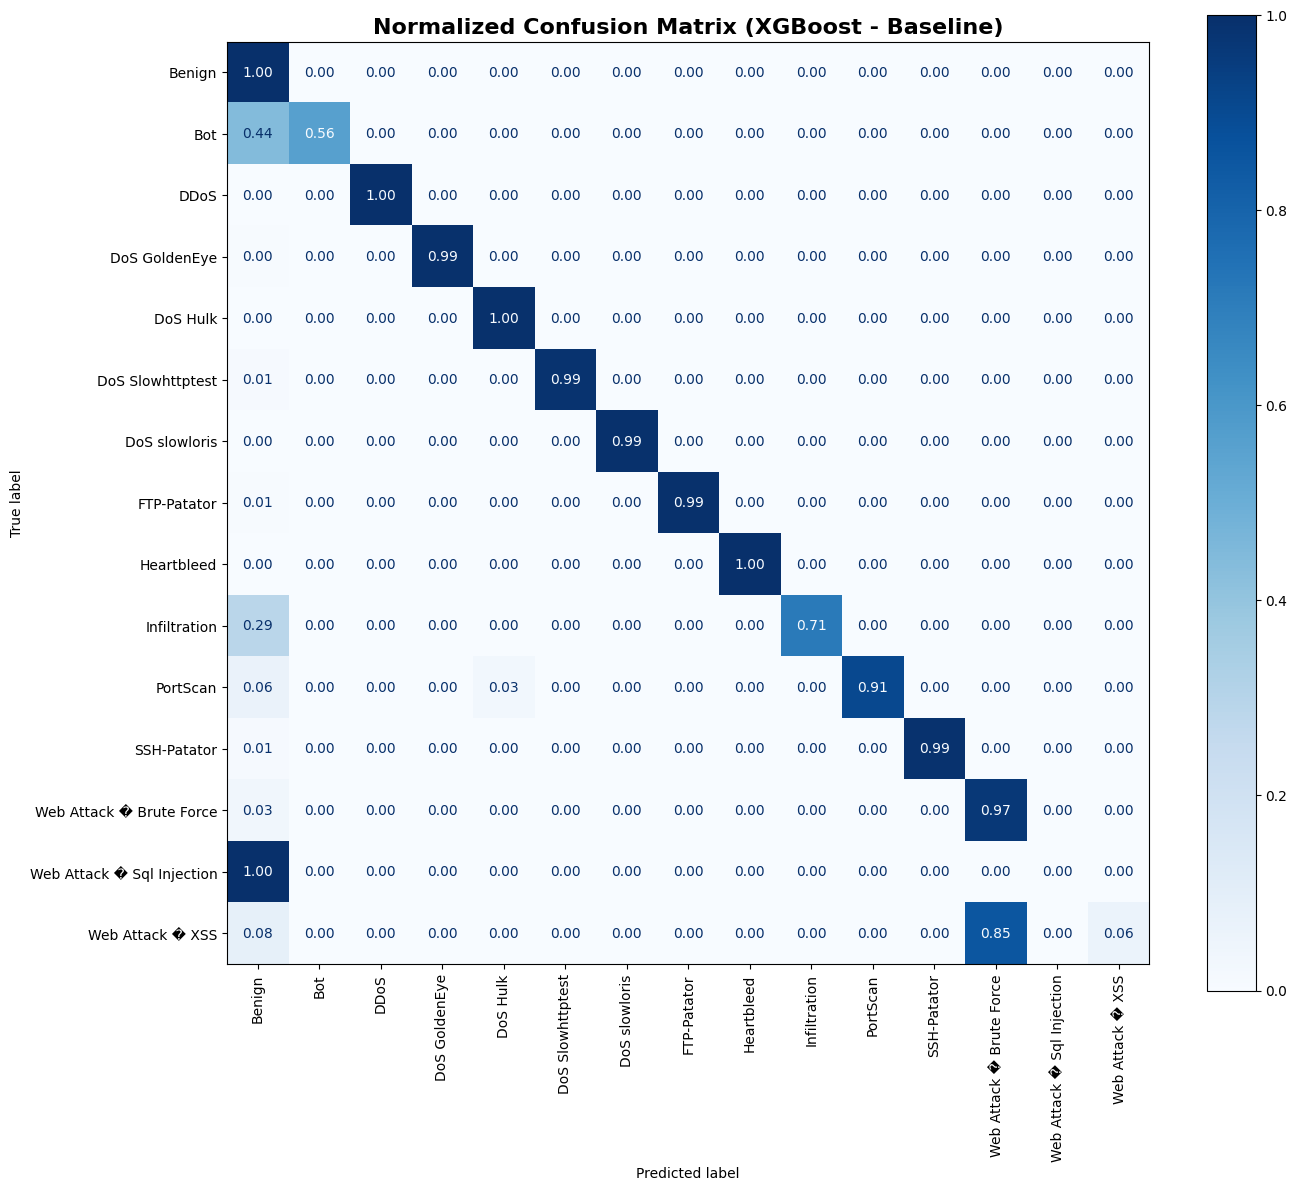

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(14, 12))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_before,
    labels=classes,
    display_labels=class_names,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=90,
    ax=ax
)

plt.title(
    "Normalized Confusion Matrix (XGBoost - Baseline)",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/xgb_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
xgb_results = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [accuracy],
    "Weighted Precision": [precision_weighted],
    "Weighted Recall": [recall_weighted],
    "Weighted F1": [f1_weighted],
    "Macro Precision": [precision_macro],
    "Macro Recall": [recall_macro],
    "Macro F1": [f1_macro],
    "MCC": [mcc],
    "AUC": [auc]
})

xgb_results.to_csv(
    "/kaggle/working/xgb_results.csv",
    index=False
)

print(xgb_results)

     Model  Accuracy  Weighted Precision  Weighted Recall  Weighted F1  \
0  XGBoost  0.998597            0.998618         0.998597     0.998455   

   Macro Precision  Macro Recall  Macro F1       MCC       AUC  
0         0.897355      0.810737  0.823679  0.994789  0.999966  


In [9]:
xgb_predictions = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_xgb_before
})

xgb_predictions.to_csv(
    "/kaggle/working/xgb_predictions.csv",
    index=False
)